# StableDiffusion and Llava-Next

## Task: Text-2-image

In [1]:
#!pip install diffusers
#!pip install accelerate

In [2]:
########### Use StableDiffusion to generate an image ############
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
pipeline = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4")
pipeline.scheduler = EulerDiscreteScheduler.from_config(pipeline.scheduler.config)

prompt = "an image of an astronaut riding a horse on the moon"
output = pipeline(prompt)
image = output.images[0]
print(type(image))

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

<class 'PIL.Image.Image'>


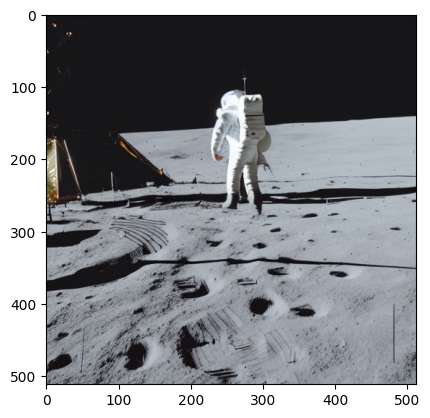

In [3]:
import matplotlib.pyplot as plt
plt.imshow(image)

In [11]:
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
import torch
processor = LlavaNextProcessor.from_pretrained("llava-hf/llama3-llava-next-8b-hf")
model = LlavaNextForConditionalGeneration.from_pretrained("llava-hf/llama3-llava-next-8b-hf", 
                                                          dtype=torch.float16) 

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
model

LlavaNextForConditionalGeneration(
  (model): LlavaNextModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)

In [13]:
# Define a chat history and use `apply_chat_template` to get correctly formatted prompt
# Each value in "content" has to be a list of dicts with types ("text", "image") 
conversation = [
    {

      "role": "user",
      "content": [
          {"type": "text", "text": "What is shown in this image?"},
          {"type": "image"},
        ],
    },
]
prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=100)

print(processor.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


user


What is shown in this image?assistant


The image shows an astronaut on the surface of the Moon. The astronaut is wearing a white spacesuit with a helmet, and is standing on the lunar regolith, which is the loose, powdery soil that covers the Moon's surface. The astronaut appears to be walking towards a structure that looks like a tent or a small shelter, which is likely part of a lunar base or a temporary setup for a mission. The image is in black and white, which gives it a classic, historical
